# 06 Feature Engineering Dự Báo

Notebook này nâng cấp baseline dự báo thành một pipeline đặc trưng có kiểm soát leakage. Notebook tạo các đặc trưng mô hình hóa hàng ngày chỉ từ dữ liệu nội bộ, so sánh các mô hình mạnh hơn với baseline notebook 05, và chọn ứng viên tốt nhất cho notebook 07.

Biến đích: `Revenue` từ `sales.csv`.

Độ chi tiết: một hàng trên mỗi ngày lịch.

## 1. Cài Đặt

In [1]:
from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

try:
    from xgboost import XGBRegressor
    HAS_XGBOOST = True
except Exception:
    HAS_XGBOOST = False

RANDOM_SEED = 2026
np.random.seed(RANDOM_SEED)

project_root = next((candidate for candidate in [Path.cwd(), *Path.cwd().parents] if (candidate / "dataset").exists()), Path.cwd())
DATA_DIR = project_root / "dataset"
ARTIFACT_DIR = project_root / "artifacts" / "modeling"
CHART_DIR = ARTIFACT_DIR / "charts"
MODEL_DIR = project_root / "models"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 160)
sns.set_theme(style="whitegrid")

print("Project root:", project_root)
print("Artifacts:", ARTIFACT_DIR)
print("XGBoost available:", HAS_XGBOOST)


Project root: C:\Users\admin\OneDrive - National Economics University\Documents\NCKH\DATATHON\Neu_BRT_Datathon
Artifacts: C:\Users\admin\OneDrive - National Economics University\Documents\NCKH\DATATHON\Neu_BRT_Datathon\artifacts\modeling
XGBoost available: True


## 2. Tải Dữ Liệu Nội Bộ

Chỉ sử dụng các file CSV được cung cấp. Không sử dụng dữ liệu ngoài và không sử dụng giá trị `Revenue` hay `COGS` thuộc giai đoạn kiểm tra.

In [2]:
sales = pd.read_csv(DATA_DIR / "sales.csv", parse_dates=["Date"]).sort_values("Date")
web_traffic = pd.read_csv(DATA_DIR / "web_traffic.csv", parse_dates=["date"])
orders = pd.read_csv(DATA_DIR / "orders.csv", parse_dates=["order_date"])
order_items = pd.read_csv(DATA_DIR / "order_items.csv")
products = pd.read_csv(DATA_DIR / "products.csv")
promotions = pd.read_csv(DATA_DIR / "promotions.csv", parse_dates=["start_date", "end_date"])
inventory = pd.read_csv(DATA_DIR / "inventory.csv", parse_dates=["snapshot_date"])
returns = pd.read_csv(DATA_DIR / "returns.csv", parse_dates=["return_date"])
reviews = pd.read_csv(DATA_DIR / "reviews.csv", parse_dates=["review_date"])
shipments = pd.read_csv(DATA_DIR / "shipments.csv", parse_dates=["ship_date", "delivery_date"])
payments = pd.read_csv(DATA_DIR / "payments.csv")

load_summary = pd.DataFrame({
    "table": ["sales", "web_traffic", "orders", "order_items", "products", "promotions", "inventory", "returns", "reviews", "shipments", "payments"],
    "rows": [len(sales), len(web_traffic), len(orders), len(order_items), len(products), len(promotions), len(inventory), len(returns), len(reviews), len(shipments), len(payments)],
})
display(load_summary)
display(sales.head())


,table,rows
0,sales,3833
1,web_traffic,3652
2,orders,646945
3,order_items,714669
4,products,2412
5,promotions,50
6,inventory,60247
7,returns,39939
8,reviews,113551
9,shipments,566067


,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


## 3. Chính Sách Leakage

Các biện pháp kiểm soát leakage được sử dụng trong notebook này:

- Các đặc trưng dẫn xuất từ đích trong `sales.csv` sử dụng `shift(1)` trước khi tính lag/rolling.
- Tập xác nhận nằm hoàn toàn sau tập huấn luyện theo thời gian.
- Các tổng hợp hàng ngày từ lưu lượng web, đơn hàng, tồn kho, trả hàng, đánh giá, vận chuyển và thanh toán được kết hợp để kiểm tra, nhưng các đặc trưng mô hình chỉ sử dụng phiên bản lagged/rolling. Các tổng hợp vận hành cùng ngày bị loại khỏi đầu vào mô hình.
- Không sử dụng giá trị `Revenue` hay `COGS` từ bất kỳ giai đoạn kiểm tra nào.

## 4. Đặc Trưng Lag, Rolling Của Sales Và Đặc Trưng Lịch

In [3]:
base = sales.copy()
base["date"] = base["Date"]
base = base[["date", "Revenue", "COGS"]].sort_values("date").reset_index(drop=True)

full_calendar = pd.DataFrame({"date": pd.date_range(base["date"].min(), base["date"].max(), freq="D")})
base = full_calendar.merge(base, on="date", how="left")

missing_target_days = base["Revenue"].isna().sum()
print("Missing target days after calendar join:", missing_target_days)

base["day_of_week"] = base["date"].dt.dayofweek
base["day_of_month"] = base["date"].dt.day
base["day_of_year"] = base["date"].dt.dayofyear
base["week_of_year"] = base["date"].dt.isocalendar().week.astype(int)
base["month"] = base["date"].dt.month
base["quarter"] = base["date"].dt.quarter
base["year"] = base["date"].dt.year
base["is_weekend"] = base["day_of_week"].isin([5, 6]).astype(int)
base["time_index"] = np.arange(len(base))

revenue_past = base["Revenue"].shift(1)
cogs_past = base["COGS"].shift(1)

for lag in [1, 7, 14, 28, 30, 60, 90, 365]:
    base[f"revenue_lag_{lag}"] = base["Revenue"].shift(lag)
    base[f"cogs_lag_{lag}"] = base["COGS"].shift(lag)

for window in [7, 14, 28, 30, 60, 90]:
    base[f"revenue_roll_mean_{window}"] = revenue_past.rolling(window, min_periods=max(2, window // 3)).mean()
    base[f"revenue_roll_std_{window}"] = revenue_past.rolling(window, min_periods=max(2, window // 3)).std()
    base[f"cogs_roll_mean_{window}"] = cogs_past.rolling(window, min_periods=max(2, window // 3)).mean()

base["revenue_ewm_7"] = revenue_past.ewm(span=7, adjust=False).mean()
base["revenue_ewm_30"] = revenue_past.ewm(span=30, adjust=False).mean()

display(base.head(10))


Missing target days after calendar join: 0


,date,Revenue,COGS,day_of_week,day_of_month,day_of_year,week_of_year,month,quarter,year,is_weekend,time_index,revenue_lag_1,cogs_lag_1,revenue_lag_7,cogs_lag_7,revenue_lag_14,cogs_lag_14,revenue_lag_28,cogs_lag_28,revenue_lag_30,cogs_lag_30,revenue_lag_60,cogs_lag_60,revenue_lag_90,cogs_lag_90,revenue_lag_365,cogs_lag_365,revenue_roll_mean_7,revenue_roll_std_7,cogs_roll_mean_7,revenue_roll_mean_14,revenue_roll_std_14,cogs_roll_mean_14,revenue_roll_mean_28,revenue_roll_std_28,cogs_roll_mean_28,revenue_roll_mean_30,revenue_roll_std_30,cogs_roll_mean_30,revenue_roll_mean_60,revenue_roll_std_60,cogs_roll_mean_60,revenue_roll_mean_90,revenue_roll_std_90,cogs_roll_mean_90,revenue_ewm_7,revenue_ewm_30
0,2012-07-04,5123547.94,3982991.19,2,4,186,27,7,3,2012,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-07-05,2751773.45,2150580.23,3,5,187,27,7,3,2012,0,1,5123547.94,3982991.19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.123548e+06,5.123548e+06
2,2012-07-06,3054029.42,2517632.84,4,6,188,27,7,3,2012,0,2,2751773.45,2150580.23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.937661e+06,1.677098e+06,3.066786e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.530604e+06,4.970530e+06
3,2012-07-07,2667930.94,2108246.62,5,7,189,27,7,3,2012,1,3,3054029.42,2517632.84,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.643117e+06,1.290967e+06,2.883735e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.161461e+06,4.846885e+06
4,2012-07-08,2360851.90,1808622.79,6,8,190,27,7,3,2012,1,4,2667930.94,2108246.62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.399320e+06,1.161383e+06,2.689863e+06,3.399320e+06,1.161383e+06,2.689863e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.788078e+06,4.706307e+06
5,2012-07-09,3548386.46,2787841.68,0,9,191,28,7,3,2012,0,5,2360851.90,1808622.79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.191627e+06,1.107832e+06,2.513615e+06,3.191627e+06,1.107832e+06,2.513615e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.431272e+06,4.554988e+06
6,2012-07-10,5234938.62,4044438.84,1,10,192,28,7,3,2012,0,6,3548386.46,2787841.68,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.251087e+06,1.001522e+06,2.559319e+06,3.251087e+06,1.001522e+06,2.559319e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.460550e+06,4.490046e+06
7,2012-07-11,5582884.78,4338313.07,2,11,193,28,7,3,2012,0,7,5234938.62,4044438.84,5123547.94,3982991.19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.534494e+06,1.182417e+06,2.771479e+06,3.534494e+06,1.182417e+06,2.771479e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.904147e+06,4.538103e+06
8,2012-07-12,5734632.02,4458811.27,3,12,194,28,7,3,2012,0,8,5582884.78,4338313.07,2751773.45,2150580.23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.600114e+06,1.292887e+06,2.822239e+06,3.790543e+06,1.312581e+06,2.967333e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.323832e+06,4.605508e+06
9,2012-07-13,5309511.71,4143402.78,4,13,195,28,7,3,2012,0,9,5734632.02,4458811.27,3054029.42,2517632.84,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.026236e+06,1.448836e+06,3.151987e+06,4.006553e+06,1.388327e+06,3.133053e+06,4.006553e+06,1.388327e+06,3133053.17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.676532e+06,4.678355e+06


## 5. Đặc Trưng Từ Các Bảng Nội Bộ Khác

In [4]:
# Web traffic: aggregate to daily grain.
web_for_agg = web_traffic.copy()
web_for_agg["session_weight"] = web_for_agg["sessions"]

def weighted_avg_by_sessions(series):
    weights = web_for_agg.loc[series.index, "session_weight"]
    if weights.sum() == 0 or series.notna().sum() == 0:
        return np.nan
    return np.average(series, weights=weights)

web_daily = (
    web_for_agg
    .groupby("date", as_index=False)
    .agg(
        web_sessions=("sessions", "sum"),
        web_unique_visitors=("unique_visitors", "sum"),
        web_page_views=("page_views", "sum"),
        web_bounce_rate=("bounce_rate", weighted_avg_by_sessions),
        web_avg_session_duration_sec=("avg_session_duration_sec", weighted_avg_by_sessions),
        web_traffic_sources=("traffic_source", "nunique"),
    )
)
web_daily["web_page_views_per_session"] = web_daily["web_page_views"] / web_daily["web_sessions"].replace(0, np.nan)

# Orders/order_items/products/payments: daily sales-operation signals.
order_lines = (
    order_items
    .merge(orders, on="order_id", how="left")
    .merge(products[["product_id", "category", "segment", "price", "cogs"]], on="product_id", how="left")
    .merge(payments[["order_id", "payment_value", "installments"]], on="order_id", how="left")
)
order_lines["date"] = order_lines["order_date"]
order_lines["line_revenue_proxy"] = order_lines["quantity"] * order_lines["unit_price"]
order_lines["line_cogs_proxy"] = order_lines["quantity"] * order_lines["cogs"]
order_lines["line_margin_proxy"] = order_lines["line_revenue_proxy"] - order_lines["line_cogs_proxy"]
order_lines["discount_rate"] = order_lines["discount_amount"] / order_lines["line_revenue_proxy"].replace(0, np.nan)
order_lines["promo_used"] = order_lines["promo_id"].notna().astype(int)

order_daily = (
    order_lines.groupby("date", as_index=False)
    .agg(
        order_count=("order_id", "nunique"),
        order_item_rows=("order_id", "size"),
        quantity_sold=("quantity", "sum"),
        avg_unit_price=("unit_price", "mean"),
        discount_amount_total=("discount_amount", "sum"),
        avg_discount_rate=("discount_rate", "mean"),
        promo_item_share=("promo_used", "mean"),
        unique_products_sold=("product_id", "nunique"),
        unique_categories_sold=("category", "nunique"),
        avg_installments=("installments", "mean"),
        payment_value_total=("payment_value", "sum"),
    )
)

# Promotions: active campaign count by day.
promo_rows = []
for row in promotions.itertuples(index=False):
    start = getattr(row, "start_date")
    end = getattr(row, "end_date")
    if pd.notna(start) and pd.notna(end):
        dates = pd.date_range(start, end, freq="D")
        promo_rows.append(pd.DataFrame({
            "date": dates,
            "promo_id": getattr(row, "promo_id"),
            "promo_type": getattr(row, "promo_type"),
            "promo_channel": getattr(row, "promo_channel"),
            "applicable_category": getattr(row, "applicable_category"),
        }))
promo_daily_raw = pd.concat(promo_rows, ignore_index=True) if promo_rows else pd.DataFrame(columns=["date", "promo_id", "promo_type", "promo_channel", "applicable_category"])
promo_daily = (
    promo_daily_raw.groupby("date", as_index=False)
    .agg(
        active_campaigns=("promo_id", "nunique"),
        active_promo_types=("promo_type", "nunique"),
        active_promo_channels=("promo_channel", "nunique"),
        active_promo_categories=("applicable_category", "nunique"),
    )
)

# Inventory: monthly snapshot mapped to all days in the same month.
inventory_monthly = (
    inventory.assign(month=inventory["snapshot_date"].dt.to_period("M").dt.to_timestamp())
    .groupby("month", as_index=False)
    .agg(
        inv_stock_on_hand=("stock_on_hand", "sum"),
        inv_units_received=("units_received", "sum"),
        inv_units_sold=("units_sold", "sum"),
        inv_stockout_days=("stockout_days", "sum"),
        inv_days_of_supply=("days_of_supply", "mean"),
        inv_fill_rate=("fill_rate", "mean"),
        inv_stockout_flag_share=("stockout_flag", "mean"),
        inv_overstock_flag_share=("overstock_flag", "mean"),
        inv_reorder_flag_share=("reorder_flag", "mean"),
        inv_sell_through_rate=("sell_through_rate", "mean"),
    )
)
month_calendar = pd.DataFrame({"date": base["date"]})
month_calendar["month"] = month_calendar["date"].dt.to_period("M").dt.to_timestamp()
inventory_daily = month_calendar.merge(inventory_monthly, on="month", how="left").drop(columns=["month"])

# Returns/reviews/shipments: aggregate event signals by their event date.
returns_daily = (
    returns.groupby("return_date", as_index=False)
    .agg(
        return_records=("return_id", "nunique"),
        return_quantity=("return_quantity", "sum"),
        refund_amount=("refund_amount", "sum"),
        return_reasons=("return_reason", "nunique"),
    )
    .rename(columns={"return_date": "date"})
)

reviews_daily = (
    reviews.groupby("review_date", as_index=False)
    .agg(
        review_count=("review_id", "nunique"),
        avg_rating=("rating", "mean"),
        low_rating_share=("rating", lambda x: np.mean(x <= 2)),
    )
    .rename(columns={"review_date": "date"})
)

shipments_daily = shipments.copy()
shipments_daily["delivery_delay_days"] = (shipments_daily["delivery_date"] - shipments_daily["ship_date"]).dt.days
shipments_daily = (
    shipments_daily.groupby("ship_date", as_index=False)
    .agg(
        shipped_orders=("order_id", "nunique"),
        avg_delivery_delay_days=("delivery_delay_days", "mean"),
        shipping_fee_total=("shipping_fee", "sum"),
        avg_shipping_fee=("shipping_fee", "mean"),
    )
    .rename(columns={"ship_date": "date"})
)

feature_sources = {
    "web_daily": web_daily,
    "order_daily": order_daily,
    "promo_daily": promo_daily,
    "inventory_daily": inventory_daily,
    "returns_daily": returns_daily,
    "reviews_daily": reviews_daily,
    "shipments_daily": shipments_daily,
}

for name, df in feature_sources.items():
    print(name, df.shape, df["date"].min(), df["date"].max())


web_daily (3652, 8) 2013-01-01 00:00:00 2022-12-31 00:00:00
order_daily (3833, 12) 2012-07-04 00:00:00 2022-12-31 00:00:00
promo_daily (1707, 5) 2013-01-31 00:00:00 2022-12-31 00:00:00
inventory_daily (3833, 11) 2012-07-04 00:00:00 2022-12-31 00:00:00
returns_daily (3806, 5) 2012-07-11 00:00:00 2022-12-31 00:00:00
reviews_daily (3825, 4) 2012-07-10 00:00:00 2022-12-31 00:00:00
shipments_daily (3831, 5) 2012-07-04 00:00:00 2022-12-29 00:00:00


## 6. Kết Hợp Vào Độ Chi Tiết Mô Hình Hóa Hàng Ngày Và Kiểm Tra Giá Trị Thiếu

In [5]:
modeling_df = base.copy()
for name, df in feature_sources.items():
    modeling_df = modeling_df.merge(df, on="date", how="left")

# Event-count features: no event means zero. Rate/average features are imputed later in model pipelines.
zero_fill_cols = [
    "web_sessions", "web_unique_visitors", "web_page_views", "web_traffic_sources",
    "order_count", "order_item_rows", "quantity_sold", "discount_amount_total",
    "unique_products_sold", "unique_categories_sold", "payment_value_total",
    "active_campaigns", "active_promo_types", "active_promo_channels", "active_promo_categories",
    "return_records", "return_quantity", "refund_amount", "return_reasons",
    "review_count", "shipped_orders", "shipping_fee_total",
]
for col in zero_fill_cols:
    if col in modeling_df.columns:
        modeling_df[col] = modeling_df[col].fillna(0)

external_raw_cols = sorted({
    col
    for df in feature_sources.values()
    for col in df.columns
    if col != "date" and col in modeling_df.columns
})

# Leakage-safe operational features: only past values are allowed for model training.
for col in external_raw_cols:
    modeling_df[f"{col}_lag_1"] = modeling_df[col].shift(1)
    modeling_df[f"{col}_roll_mean_7"] = modeling_df[col].shift(1).rolling(7, min_periods=2).mean()

missing_summary = (
    modeling_df.isna().sum()
    .reset_index()
    .rename(columns={"index": "feature", 0: "missing_count"})
)
missing_summary["missing_pct"] = missing_summary["missing_count"] / len(modeling_df)
missing_summary = missing_summary.sort_values(["missing_count", "feature"], ascending=[False, True])

display(modeling_df.head())
display(missing_summary[missing_summary["missing_count"] > 0].head(30))
print("Final modeling grain: one row per date")
print("Same-day operational columns excluded from model features:", len(external_raw_cols))
print("Shape:", modeling_df.shape)


,date,Revenue,COGS,day_of_week,day_of_month,day_of_year,week_of_year,month,quarter,year,is_weekend,time_index,revenue_lag_1,cogs_lag_1,revenue_lag_7,cogs_lag_7,revenue_lag_14,cogs_lag_14,revenue_lag_28,cogs_lag_28,revenue_lag_30,cogs_lag_30,revenue_lag_60,cogs_lag_60,revenue_lag_90,cogs_lag_90,revenue_lag_365,cogs_lag_365,revenue_roll_mean_7,revenue_roll_std_7,cogs_roll_mean_7,revenue_roll_mean_14,revenue_roll_std_14,cogs_roll_mean_14,revenue_roll_mean_28,revenue_roll_std_28,cogs_roll_mean_28,revenue_roll_mean_30,revenue_roll_std_30,cogs_roll_mean_30,revenue_roll_mean_60,revenue_roll_std_60,cogs_roll_mean_60,revenue_roll_mean_90,revenue_roll_std_90,cogs_roll_mean_90,revenue_ewm_7,revenue_ewm_30,web_sessions,web_unique_visitors,web_page_views,web_bounce_rate,web_avg_session_duration_sec,web_traffic_sources,web_page_views_per_session,order_count,order_item_rows,quantity_sold,avg_unit_price,discount_amount_total,avg_discount_rate,promo_item_share,unique_products_sold,unique_categories_sold,avg_installments,payment_value_total,active_campaigns,active_promo_types,active_promo_channels,active_promo_categories,inv_stock_on_hand,inv_units_received,inv_units_sold,inv_stockout_days,inv_days_of_supply,inv_fill_rate,inv_stockout_flag_share,inv_overstock_flag_share,inv_reorder_flag_share,inv_sell_through_rate,return_records,return_quantity,refund_amount,return_reasons,review_count,avg_rating,low_rating_share,shipped_orders,avg_delivery_delay_days,shipping_fee_total,avg_shipping_fee,active_campaigns_lag_1,active_campaigns_roll_mean_7,active_promo_categories_lag_1,active_promo_categories_roll_mean_7,active_promo_channels_lag_1,active_promo_channels_roll_mean_7,active_promo_types_lag_1,active_promo_types_roll_mean_7,avg_delivery_delay_days_lag_1,avg_delivery_delay_days_roll_mean_7,avg_discount_rate_lag_1,avg_discount_rate_roll_mean_7,avg_installments_lag_1,avg_installments_roll_mean_7,avg_rating_lag_1,avg_rating_roll_mean_7,avg_shipping_fee_lag_1,avg_shipping_fee_roll_mean_7,avg_unit_price_lag_1,avg_unit_price_roll_mean_7,discount_amount_total_lag_1,discount_amount_total_roll_mean_7,inv_days_of_supply_lag_1,inv_days_of_supply_roll_mean_7,inv_fill_rate_lag_1,inv_fill_rate_roll_mean_7,inv_overstock_flag_share_lag_1,inv_overstock_flag_share_roll_mean_7,inv_reorder_flag_share_lag_1,inv_reorder_flag_share_roll_mean_7,inv_sell_through_rate_lag_1,inv_sell_through_rate_roll_mean_7,inv_stock_on_hand_lag_1,inv_stock_on_hand_roll_mean_7,inv_stockout_days_lag_1,inv_stockout_days_roll_mean_7,inv_stockout_flag_share_lag_1,inv_stockout_flag_share_roll_mean_7,inv_units_received_lag_1,inv_units_received_roll_mean_7,inv_units_sold_lag_1,inv_units_sold_roll_mean_7,low_rating_share_lag_1,low_rating_share_roll_mean_7,order_count_lag_1,order_count_roll_mean_7,order_item_rows_lag_1,order_item_rows_roll_mean_7,payment_value_total_lag_1,payment_value_total_roll_mean_7,promo_item_share_lag_1,promo_item_share_roll_mean_7,quantity_sold_lag_1,quantity_sold_roll_mean_7,refund_amount_lag_1,refund_amount_roll_mean_7,return_quantity_lag_1,return_quantity_roll_mean_7,return_reasons_lag_1,return_reasons_roll_mean_7,return_records_lag_1,return_records_roll_mean_7,review_count_lag_1,review_count_roll_mean_7,shipped_orders_lag_1,shipped_orders_roll_mean_7,shipping_fee_total_lag_1,shipping_fee_total_roll_mean_7,unique_categories_sold_lag_1,unique_categories_sold_roll_mean_7,unique_products_sold_lag_1,unique_products_sold_roll_mean_7,web_avg_session_duration_sec_lag_1,web_avg_session_duration_sec_roll_mean_7,web_bounce_rate_lag_1,web_bounce_rate_roll_mean_7,web_page_views_lag_1,web_page_views_roll_mean_7,web_page_views_per_session_lag_1,web_page_views_per_session_roll_mean_7,web_sessions_lag_1,web_sessions_roll_mean_7,web_traffic_sources_lag_1,web_traffic_sources_roll_mean_7,web_unique_visitors_lag_1,web_unique_visitors_roll_mean_7
0,2012-07-04,5123547.94,3982991.19,2,4,186,27,7,3,2012,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

,feature,missing_count,missing_pct
27,cogs_lag_365,365,0.095226
26,revenue_lag_365,365,0.095226
164,web_avg_session_duration_sec_roll_mean_7,183,0.047743
166,web_bounce_rate_roll_mean_7,183,0.047743
170,web_page_views_per_session_roll_mean_7,183,0.047743
163,web_avg_session_duration_sec_lag_1,182,0.047482
165,web_bounce_rate_lag_1,182,0.047482
169,web_page_views_per_session_lag_1,182,0.047482
52,web_avg_session_duration_sec,181,0.047221
51,web_bounce_rate,181,0.047221


Final modeling grain: one row per date
Same-day operational columns excluded from model features: 43
Shape: (3833, 177)


## 7. Danh Sách Đặc Trưng

In [6]:
target_cols = ["Revenue", "COGS"]
id_cols = ["date"]

leakage_excluded_cols = set(external_raw_cols)
feature_cols = [c for c in modeling_df.columns if c not in target_cols + id_cols and c not in leakage_excluded_cols]

def feature_source(col):
    if col.startswith(("revenue_lag", "revenue_roll", "revenue_ewm", "cogs_lag", "cogs_roll")):
        return "sales.csv lag/rolling past-only"
    if col in ["day_of_week", "day_of_month", "day_of_year", "week_of_year", "month", "quarter", "year", "is_weekend", "time_index"]:
        return "calendar from Date"
    if col.endswith("_lag_1") or col.endswith("_roll_mean_7"):
        raw = col.replace("_lag_1", "").replace("_roll_mean_7", "")
        return f"lagged/rolling past-only operational feature from {raw}"
    if col.startswith("web_"):
        return "web_traffic.csv raw same-day aggregate (excluded if unlagged)"
    if col.startswith(("order_", "quantity_", "avg_unit", "discount_", "avg_discount", "promo_item", "unique_", "avg_installments", "payment_value")):
        return "orders/order_items/products/payments raw same-day aggregate (excluded if unlagged)"
    if col.startswith("active_"):
        return "promotions.csv raw active daily campaigns (excluded if unlagged)"
    if col.startswith("inv_"):
        return "inventory.csv raw monthly mapped to date month (excluded if unlagged)"
    if col.startswith(("return_", "refund_")):
        return "returns.csv raw daily aggregate (excluded if unlagged)"
    if col.startswith(("review_", "avg_rating", "low_rating")):
        return "reviews.csv raw daily aggregate (excluded if unlagged)"
    if col.startswith(("shipped_", "avg_delivery", "shipping_")):
        return "shipments.csv raw daily aggregate (excluded if unlagged)"
    return "other"

feature_list = pd.DataFrame({
    "feature": feature_cols,
    "source": [feature_source(c) for c in feature_cols],
    "missing_count": [int(modeling_df[c].isna().sum()) for c in feature_cols],
    "dtype": [str(modeling_df[c].dtype) for c in feature_cols],
    "used_in_model": True,
})

feature_list.to_csv(ARTIFACT_DIR / "feature_list.csv", index=False, encoding="utf-8-sig")
display(feature_list)


,feature,source,missing_count,dtype,used_in_model
0,day_of_week,calendar from Date,0,int32,True
1,day_of_month,calendar from Date,0,int32,True
2,day_of_year,calendar from Date,0,int32,True
3,week_of_year,calendar from Date,0,int64,True
4,month,calendar from Date,0,int32,True
...,...,...,...,...,...
126,web_sessions_roll_mean_7,lagged/rolling past-only operational feature from web_sessions,2,float64,True
127,web_traffic_sources_lag_1,lagged/rolling past-only operational feature from web_traffic_sources,1,float64,True
128,web_traffic_sources_roll_mean_7,lagged/rolling past-only operational feature from web_traffic_sources,2,float64,True
129,web_unique_visitors_lag_1,lagged/rolling past-only operational feature from web_unique_visitors,1,float64,True


## 8. Phân Chia Tập Xác Nhận Theo Thời Gian

In [7]:
validation_start = pd.Timestamp("2022-01-01")
validation_end = sales["Date"].max()

# Drop early rows without enough sales history for lag/rolling features.
model_ready = modeling_df.dropna(subset=["Revenue", "revenue_lag_365", "revenue_roll_mean_90"]).copy()

train_df = model_ready[model_ready["date"] < validation_start].copy()
valid_df = model_ready[(model_ready["date"] >= validation_start) & (model_ready["date"] <= validation_end)].copy()

split_summary = pd.DataFrame([{
    "train_start": train_df["date"].min(),
    "train_end": train_df["date"].max(),
    "train_rows": len(train_df),
    "validation_start": valid_df["date"].min(),
    "validation_end": valid_df["date"].max(),
    "validation_rows": len(valid_df),
}])
display(split_summary)


,train_start,train_end,train_rows,validation_start,validation_end,validation_rows
0,2013-07-04,2021-12-31,3103,2022-01-01,2022-12-31,365


## 9. Huấn Luyện Các Mô Hình

In [8]:
def metrics_df(y_true, y_pred, model_name):
    return pd.DataFrame([{
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }])

X_train = train_df[feature_cols]
y_train = train_df["Revenue"]
X_valid = valid_df[feature_cols]
y_valid = valid_df["Revenue"]

numeric_features = feature_cols
numeric_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

tree_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

models = {
    "linear_regression": Pipeline(steps=[
        ("preprocess", numeric_preprocess),
        ("model", LinearRegression()),
    ]),
    "ridge": Pipeline(steps=[
        ("preprocess", numeric_preprocess),
        ("model", Ridge(alpha=10.0, random_state=RANDOM_SEED)),
    ]),
    "random_forest": Pipeline(steps=[
        ("preprocess", tree_preprocess),
        ("model", RandomForestRegressor(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=5,
            random_state=RANDOM_SEED,
            n_jobs=-1,
        )),
    ]),
}

if HAS_XGBOOST:
    models["xgboost"] = Pipeline(steps=[
        ("preprocess", tree_preprocess),
        ("model", XGBRegressor(
            n_estimators=500,
            max_depth=4,
            learning_rate=0.03,
            subsample=0.85,
            colsample_bytree=0.85,
            objective="reg:squarederror",
            random_state=RANDOM_SEED,
            n_jobs=4,
        )),
    ])

prediction_frames = []
result_frames = []
fitted_models = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_valid)
    fitted_models[model_name] = model
    prediction_frames.append(pd.DataFrame({
        "date": valid_df["date"].values,
        "actual": y_valid.values,
        "forecast": pred,
        "model": model_name,
    }))
    result_frames.append(metrics_df(y_valid, pred, model_name))

model_results = pd.concat(result_frames, ignore_index=True).sort_values(["RMSE", "MAE"])
validation_predictions = pd.concat(prediction_frames, ignore_index=True)

display(model_results)


,model,MAE,RMSE,R2
3,xgboost,563079.858130,781608.612500,0.781945
1,ridge,609092.971465,810857.842797,0.765319
0,linear_regression,632168.668098,831720.322416,0.753088
2,random_forest,593005.659796,846196.971271,0.744418


## 10. So Sánh Với Baseline Notebook 05

In [9]:
baseline_score_path = project_root / "artifacts" / "forecast_baseline" / "baseline_score_table.csv"
if baseline_score_path.exists():
    baseline_scores = pd.read_csv(baseline_score_path)
    selected_baseline = baseline_scores.sort_values(["RMSE", "MAE"]).head(1).copy()
    selected_baseline["model"] = "baseline_05_" + selected_baseline["model"]
else:
    selected_baseline = pd.DataFrame([{
        "model": "baseline_05_unavailable",
        "MAE": np.nan,
        "RMSE": np.nan,
        "R2": np.nan,
    }])

comparison_table = (
    pd.concat([selected_baseline[["model", "MAE", "RMSE", "R2"]], model_results], ignore_index=True)
    .sort_values(["RMSE", "MAE"], na_position="last")
    .reset_index(drop=True)
)
comparison_table["rank"] = np.arange(1, len(comparison_table) + 1)
display(comparison_table)


,model,MAE,RMSE,R2,rank
0,xgboost,5.630799e+05,7.816086e+05,0.781945,1
1,ridge,6.090930e+05,8.108578e+05,0.765319,2
2,linear_regression,6.321687e+05,8.317203e+05,0.753088,3
3,random_forest,5.930057e+05,8.461970e+05,0.744418,4
4,baseline_05_linear_time_features,1.016413e+06,1.416690e+06,0.283630,5


## 11. Tầm Quan Trọng Của Đặc Trưng (Feature Importance)

,feature,importance
93,payment_value_total_lag_1,0.263587
9,revenue_lag_1,0.214128
24,cogs_lag_365,0.068432
23,revenue_lag_365,0.016882
83,inv_units_received_lag_1,0.015493
11,revenue_lag_7,0.014770
13,revenue_lag_14,0.013024
15,revenue_lag_28,0.012604
12,cogs_lag_7,0.012033
112,shipping_fee_total_roll_mean_7,0.010216


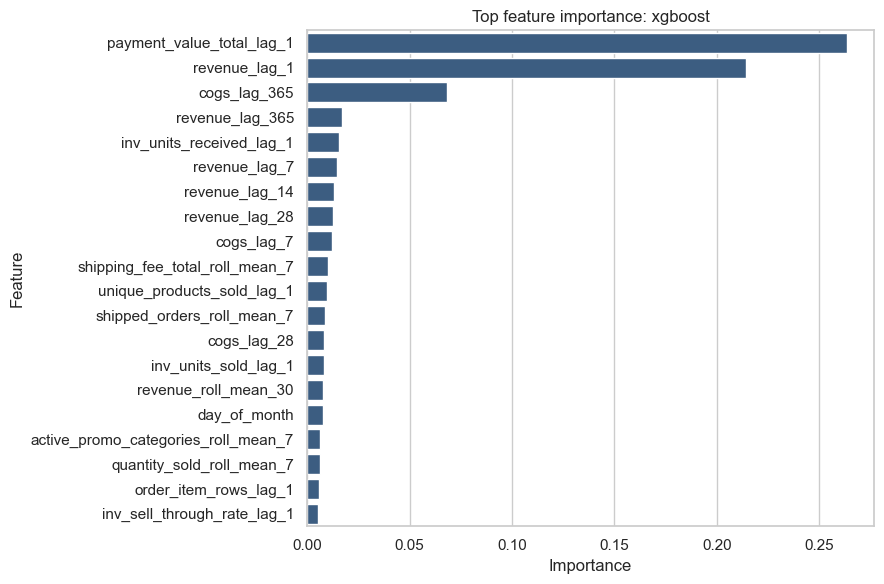

In [10]:
best_model_name = model_results.iloc[0]["model"]
best_model = fitted_models[best_model_name]

importance_df = pd.DataFrame()
estimator = best_model.named_steps["model"]

if hasattr(estimator, "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature": feature_cols,
        "importance": estimator.feature_importances_,
    }).sort_values("importance", ascending=False)
elif hasattr(estimator, "coef_"):
    importance_df = pd.DataFrame({
        "feature": feature_cols,
        "importance": np.abs(estimator.coef_),
    }).sort_values("importance", ascending=False)

display(importance_df.head(25))

if not importance_df.empty:
    plt.figure(figsize=(9, 6))
    sns.barplot(data=importance_df.head(20), y="feature", x="importance", color="#315C8C")
    plt.title(f"Top feature importance: {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.savefig(CHART_DIR / "feature_importance_top20.png", dpi=160)
    plt.show()


## 12. Thực Tế So Với Dự Báo Cho Ứng Viên Tốt Nhất

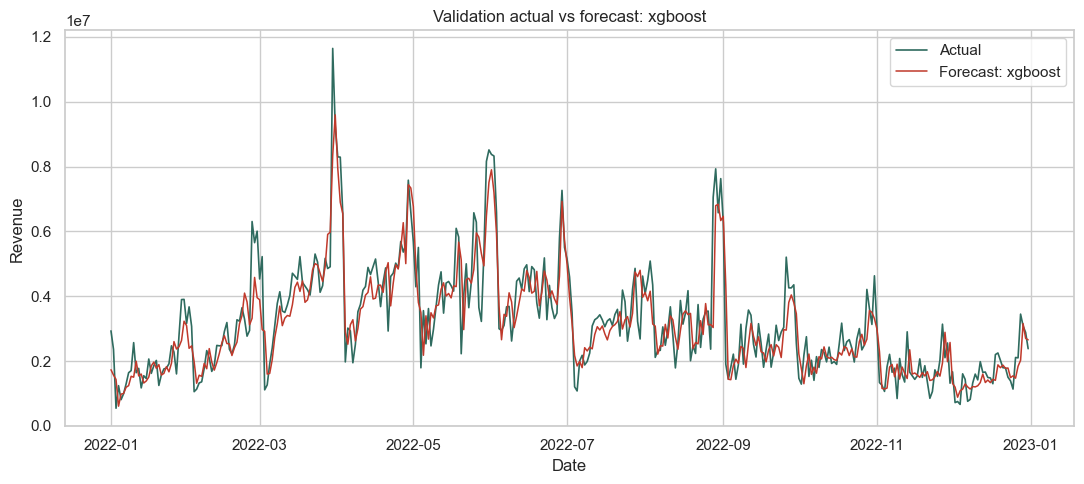

,residual
count,3.650000e+02
mean,1.245772e+05
std,7.726760e+05
min,-2.897825e+06
25%,-2.661496e+05
50%,1.462073e+05
75%,5.012569e+05
max,4.016886e+06


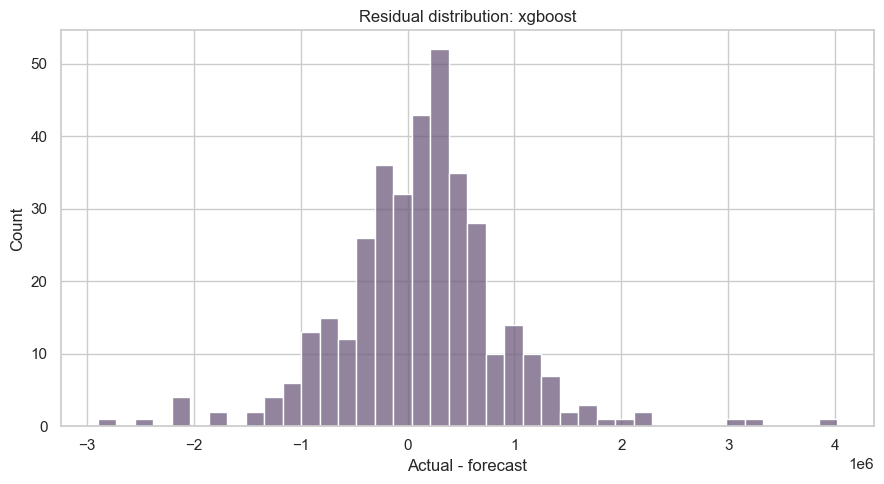

In [11]:
best_predictions = validation_predictions[validation_predictions["model"] == best_model_name].copy()
best_predictions["residual"] = best_predictions["actual"] - best_predictions["forecast"]

plt.figure(figsize=(11, 5))
plt.plot(best_predictions["date"], best_predictions["actual"], label="Actual", color="#2F6B5F", linewidth=1.2)
plt.plot(best_predictions["date"], best_predictions["forecast"], label=f"Forecast: {best_model_name}", color="#C0392B", linewidth=1.1)
plt.title(f"Validation actual vs forecast: {best_model_name}")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.tight_layout()
plt.savefig(CHART_DIR / "best_model_actual_vs_forecast.png", dpi=160)
plt.show()

residual_summary = best_predictions["residual"].describe().to_frame("residual")
display(residual_summary)

plt.figure(figsize=(9, 5))
sns.histplot(best_predictions["residual"], bins=40, color="#6C5B7B")
plt.title(f"Residual distribution: {best_model_name}")
plt.xlabel("Actual - forecast")
plt.tight_layout()
plt.savefig(CHART_DIR / "best_model_residual_distribution.png", dpi=160)
plt.show()


## 13. Lưu Tập Dữ Liệu Mô Hình Hóa, Dự Báo, Kết Quả Và Mô Hình Tốt Nhất

In [12]:
modeling_df.to_csv(ARTIFACT_DIR / "modeling_dataset_daily.csv", index=False, encoding="utf-8-sig")
model_ready.to_csv(ARTIFACT_DIR / "modeling_dataset_ready.csv", index=False, encoding="utf-8-sig")
model_results.to_csv(ARTIFACT_DIR / "model_results_feature_engineering.csv", index=False, encoding="utf-8-sig")
comparison_table.to_csv(ARTIFACT_DIR / "model_vs_baseline_comparison.csv", index=False, encoding="utf-8-sig")
validation_predictions.to_csv(ARTIFACT_DIR / "validation_predictions_feature_engineering.csv", index=False, encoding="utf-8-sig")
best_predictions.to_csv(ARTIFACT_DIR / "best_model_validation_predictions.csv", index=False, encoding="utf-8-sig")
residual_summary.to_csv(ARTIFACT_DIR / "best_model_residual_summary.csv", encoding="utf-8-sig")
importance_df.to_csv(ARTIFACT_DIR / "feature_importance.csv", index=False, encoding="utf-8-sig")

best_candidate = pd.DataFrame([{
    "best_candidate_for_notebook_07": best_model_name,
    "selection_metric": "lowest validation RMSE",
    "validation_start": valid_df["date"].min(),
    "validation_end": valid_df["date"].max(),
    "MAE": float(model_results.iloc[0]["MAE"]),
    "RMSE": float(model_results.iloc[0]["RMSE"]),
    "R2": float(model_results.iloc[0]["R2"]),
    "modeling_grain": "one row per date",
    "leakage_note": "Sales-derived features are shifted; operational aggregates are lagged/rolling past-only; no external data or test Revenue/COGS used.",
}])
best_candidate.to_csv(ARTIFACT_DIR / "best_candidate_for_notebook_07.csv", index=False, encoding="utf-8-sig")

joblib.dump(best_model, MODEL_DIR / "best_feature_engineering_model.joblib")

display(best_candidate)


,best_candidate_for_notebook_07,selection_metric,validation_start,validation_end,MAE,RMSE,R2,modeling_grain,leakage_note
0,xgboost,lowest validation RMSE,2022-01-01,2022-12-31,563079.85813,781608.6125,0.781945,one row per date,Sales-derived features are shifted; operational aggregates are lagged/rolling past-only; no external data or test Revenue/COGS used.


## 14. Quyết Định Cho Notebook 07

Mô hình được chọn là ứng viên có hiệu suất xác nhận tốt nhất theo RMSE. Notebook 07 nên cải thiện từ đây bằng cách thêm rolling validation mạnh hơn, xử lý đặc trưng sẵn có trong tương lai tốt hơn, tinh chỉnh mô hình và khả năng giải thích.